In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models, datasets
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import os


In [2]:
train_dir = "/content/drive/MyDrive/efficientnet/Train"
test_dir = "/content/drive/MyDrive/efficientnet/Test"
batch_size = 32
learning_rate = 0.001
num_epochs = 25
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [3]:

train_transforms = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
test_transforms = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


In [4]:
train_dataset = datasets.ImageFolder(root='/content/drive/MyDrive/efficientnet/Train', transform=train_transforms)
test_dataset = datasets.ImageFolder(root='/content/drive/MyDrive/efficientnet/Test', transform=test_transforms)
batch_size = 16
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)


In [5]:
aneurysm_types = ['Dissecting Aneurysm', 'Fusiform Aneurysm', 'Mycotic Aneurysm', 'Saccular Aneurysm']
severity_levels = ['Medium', 'Low', 'High']
aneurysm_type_mapping = {'Dissecting Aneurysm': 0, 'Fusiform Aneurysm': 1, 'Mycotic Aneurysm': 2, 'Saccular Aneurysm': 3}
severity_level_mapping = {'Medium': 0, 'Low': 1, 'High': 2}


In [6]:
model = models.efficientnet_b4(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B4_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B4_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth
100%|██████████| 74.5M/74.5M [00:00<00:00, 158MB/s]


In [ ]:

def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['Train', 'Test']:
            if phase == 'Train':
                model.train()
            else:
                model.eval()

            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'Train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'Train':
                        loss.backward()
                        optimizer.step()

                running_corrects += torch.sum(preds == labels.data)

            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            if epoch_acc > best_acc:
                best_acc = epoch_acc

        scheduler.step()

        print(f'Accuracy: {best_acc:.4f}')

    print(f'Best Accuracy: {best_acc:.4f}')
    return model

model = train_model(model, criterion, optimizer, scheduler, num_epochs=25)

Epoch 0/24
----------
Accuracy: 0.6005
Epoch 1/24
----------
Accuracy: 0.7113
Epoch 2/24
----------
Accuracy: 0.8116
Epoch 3/24
----------
Accuracy: 0.8203
Epoch 4/24
----------
Accuracy: 0.8738
Epoch 5/24
----------
Accuracy: 0.8987
Epoch 6/24
----------
Accuracy: 0.9120
Epoch 7/24
----------
Accuracy: 0.9446
Epoch 8/24
----------
Accuracy: 0.9484
Epoch 9/24
----------
Accuracy: 0.9484
Epoch 10/24
----------
Accuracy: 0.9541
Epoch 11/24
----------
Accuracy: 0.9560
Epoch 12/24
----------
Accuracy: 0.9579
Epoch 13/24
----------
Accuracy: 0.9656
Epoch 14/24
----------
Accuracy: 0.9656
Epoch 15/24
----------
Accuracy: 0.9656
Epoch 16/24
----------
Accuracy: 0.9675
Epoch 17/24
----------
Accuracy: 0.9675
Epoch 18/24
----------
Accuracy: 0.9675
Epoch 19/24
----------
Accuracy: 0.9713
Epoch 20/24
----------
Accuracy: 0.9713
Epoch 21/24
----------
Accuracy: 0.9713
Epoch 22/24
----------
Accuracy: 0.9713
Epoch 23/24
----------
Accuracy: 0.9713
Epoch 24/24
----------
Accuracy: 0.9713
Best Accur

In [8]:
model_path = "/content/drive/MyDrive/efficientnet/model.pth"
model.eval()


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

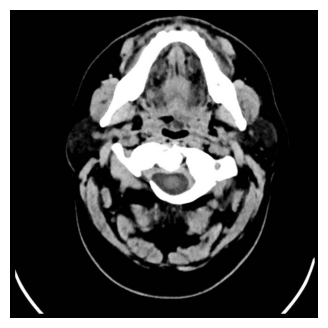

Aneurysm Type: Dissecting Aneurysm
Severity Level: High
Consequences: Severe headaches, Risk of rupture, Impaired brain function
Precautions: Emergency medical care, Limit physical exertion, Strict monitoring


In [10]:
from PIL import Image
import matplotlib.pyplot as plt

encoded_data = {
    'Dissecting Aneurysm/High': ("Severe headaches, Risk of rupture, Impaired brain function", "Emergency medical care, Limit physical exertion, Strict monitoring"),
    'Dissecting Aneurysm/Medium': ("Blurred vision, Moderate headaches, Fatigue", "Monitor blood pressure, Avoid heavy stress, Follow up regularly"),
    'Dissecting Aneurysm/Low': ("Mild headaches, Fatigue, Slight vision issues", "Regular check-ups, Mild pain relief, Stay hydrated"),
    'Fusiform Aneurysm/High': ("Severe swelling, High rupture risk, Neurological impairment", "Immediate hospitalization, Minimize movement, Continuous monitoring"),
    'Fusiform Aneurysm/Medium': ("Increased pressure, Risk of thrombosis, Moderate headaches", "Blood pressure control, Regular scans, Stress reduction"),
    'Fusiform Aneurysm/Low': ("Mild swelling, Dizziness, Slight headaches", "Regular monitoring, Balanced diet, Stress management"),
    'Mycotic Aneurysm/High': ("Severe infection, Sepsis risk, High fever", "Immediate surgery, ICU care, Emergency intervention"),
    'Mycotic Aneurysm/Medium': ("Increased infection, Risk of rupture, Moderate fever", "IV antibiotics, Close monitoring, Avoid stress"),
    'Mycotic Aneurysm/Low': ("Mild infection, Fatigue, Slight fever", "Antibiotic therapy, Rest, Regular follow-up"),
    'Saccular Aneurysm/High': ("Severe pain, High rupture risk, Neurological issues", "Emergency care, Limited activity, Close observation"),
    'Saccular Aneurysm/Medium': ("Increased discomfort, Moderate headaches, Vision problems", "Medication management, Avoid heavy stress, Regular CT scans"),
    'Saccular Aneurysm/Low': ("Mild discomfort, Slight dizziness, Occasional headaches", "Routine follow-ups, Healthy lifestyle, Stress management")
}

def analyze_image_path(image_path):

    image = Image.open(image_path).convert('RGB')
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    #plt.title("Uploaded Image")
    plt.show()


    path_parts = image_path.split('/')
    aneurysm_type = path_parts[-3]
    severity_level = path_parts[-2]


    key = f"{aneurysm_type}/{severity_level}"
    if key in encoded_data:
        consequences, precautions = encoded_data[key]
    else:
        consequences, precautions = "No data available", "No data available"

    print(f"Aneurysm Type: {aneurysm_type}")
    print(f"Severity Level: {severity_level}")
    print(f"Consequences: {consequences}")
    print(f"Precautions: {precautions}")

image_path = "/content/drive/MyDrive/efficientnet/Test/Dissecting Aneurysm/High/58 (3).jpg"
analyze_image_path(image_path)
